***Dependencies***

---



In [1]:
!pip install -q ultralytics pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00


***Code***

---



In [2]:
import glob
import os
from pathlib import Path
import shutil
import urllib.request
import yaml
import zipfile
from ultralytics import YOLO

# 1. Setup paths
dataset_dir = "/content/dataset"
target_zip = "/content/TheDataset.zip"
weights_path = "/content/yolov8s.pt"

# Clean up existing folder for a fresh start
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)
os.makedirs(dataset_dir, exist_ok=True)

# Find zip file in /content
if not os.path.exists(target_zip):
    zips = glob.glob("/content/*.zip")
    if zips:
        target_zip = zips[0]
        print(f"📁 Found dataset zip file: {target_zip}")
    else:
        raise FileNotFoundError(
            "❌ No zip file found in /content! Please ensure your Auta export zip is uploaded."
        )

# 2. Extract main zip file
print("📦 Extracting primary dataset zip...")
with zipfile.ZipFile(target_zip, "r") as zip_ref:
    zip_ref.extractall(dataset_dir)

# 3. Automatically unpack any nested zip files (Common in Auta multi-task exports)
nested_zips = glob.glob(f"{dataset_dir}/**/*.zip", recursive=True)
if nested_zips:
    print(f"📦 Found {len(nested_zips)} nested zip file(s). Unpacking...")
    for nzip in nested_zips:
        dest_folder = os.path.dirname(nzip)
        with zipfile.ZipFile(nzip, "r") as z:
            z.extractall(dest_folder)
        os.remove(nzip)

# 4. Recursively scan all folders for images (case-insensitive format check)
valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tiff",
    ".jp2",
    ".heic",
}
all_images = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if Path(file).suffix.lower() in valid_extensions:
            all_images.append(os.path.abspath(os.path.join(root, file)))

print(
    f"✅ Successfully found {len(all_images)} total images across all extracted folders!"
)

if len(all_images) == 0:
    print("\n❌ Directory Tree Inspection (no images detected):")
    for root, dirs, files in os.walk(dataset_dir):
        print(f"Folder: {root} -> Files: {files[:5]}")
    raise ValueError(
        "No image files found. Please check if the Auta export finished completely."
    )

# 5. Create train.txt manifest with absolute image paths
train_txt_path = os.path.join(dataset_dir, "train.txt")
with open(train_txt_path, "w") as f:
    for img in sorted(all_images):
        f.write(f"{img}\n")

# 6. Locate or create data.yaml
yaml_files = glob.glob(f"{dataset_dir}/**/data.yaml", recursive=True)

if yaml_files:
    yaml_path = yaml_files[0]
    with open(yaml_path, "r") as f:
        config = yaml.safe_load(f) or {}
else:
    yaml_path = os.path.join(dataset_dir, "data.yaml")
    config = {
        "names": {0: "fungal_infection", 1: "pest_damage", 2: "leaf_anomaly"}
    }

config["path"] = dataset_dir
config["train"] = train_txt_path
config["val"] = train_txt_path

with open(yaml_path, "w") as f:
    yaml.dump(config, f)

print(f"⚙️ Configured data.yaml at: {yaml_path}")

# 7. Pre-download weights if missing
if not os.path.exists(weights_path):
    print("⬇️ Pre-downloading yolov8s.pt...")
    url = "https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8s.pt"
    urllib.request.urlretrieve(url, weights_path)

# 8. Start YOLO Training
model = YOLO(weights_path)

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=800,
    batch=16,
    patience=20,
    degrees=15.0,
    fliplr=0.5,
    mosaic=1.0,
    project="leaf_disease_run",
    name="train_v2",
    exist_ok=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📁 Found dataset zip file: /content/TheDatasetV2.zip
📦 Extracting primary dataset zip...
✅ Successfully found 600 total images across all extracted folders!
⚙️ Configured data.yaml at: /content/dataset/data.yaml
⬇️ Pre-downloading yolov8s.pt...
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, 

***Export***

---



In [3]:
import shutil
from google.colab import files

file = '_v2'

# 1. Zip the train-4 directory
shutil.make_archive(f'train-{file}', 'zip', f'/content/runs/detect/leaf_disease_run/train{file}')

# 2. Trigger browser download
files.download(f'train{file}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Delete Training Data***

---



In [6]:
!rm -rf /content/runs/detect/leaf_disease_run/train

***Create train.py***

---



In [ ]:
import os
import shutil

# Create src directory
os.makedirs("src", exist_ok=True)

train_code = '''
import os
import yaml
import urllib.request
from ultralytics import YOLO

def train():
    dataset_dir = "/content/dataset"
    yaml_path = os.path.join(dataset_dir, "data.yaml")
    weights_path = "yolov8n.pt"

    # Pre-download base weights if missing
    if not os.path.exists(weights_path):
        print("⬇️ Downloading base model weights (yolov8n.pt)...")
        url = "https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8n.pt"
        urllib.request.urlretrieve(url, weights_path)

    # Initialize and train
    model = YOLO(weights_path)
    results = model.train(
        data=yaml_path,
        epochs=50,
        imgsz=640,
        batch=16,
        project="leaf_disease_run",
        name="train",
        exist_ok=True
    )
    print("✅ Training complete!")

if __name__ == "__main__":
    train()
'''

with open("src/train.py", "w") as f:
    f.write(train_code)

print("✅ Created src/train.py")

***Create predict.py***

---



In [ ]:
predict_code = '''
import sys
from ultralytics import YOLO

def predict(image_path, weights_path="best.pt"):
    # Load trained model
    model = YOLO(weights_path)

    # Perform inference
    results = model(image_path)

    # Display bounding box output
    results[0].show()

    # Save output image
    results[0].save(filename="prediction_output.jpg")
    print("✅ Prediction saved to prediction_output.jpg")

if __name__ == "__main__":
    img_path = sys.argv[1] if len(sys.argv) > 1 else "test.jpg"
    predict(img_path)
'''

with open("src/predict.py", "w") as f:
    f.write(predict_code)

print("✅ Created src/predict.py")

***Testing the Model***

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving viburnum-lg.gif to viburnum-lg.gif
Saving EXT-Hort-Powdery-Mildews-fig1.webp to EXT-Hort-Powdery-Mildews-fig1.webp
Saving images (3).jpg to images (3).jpg
Saving powdery-mildew-powdery-mildew-on-squash-leaf-shutterstock-com_13365.jpg to powdery-mildew-powdery-mildew-on-squash-leaf-shutterstock-com_13365.jpg
Saving images (2).jpg to images (2).jpg
Saving hyc2tlux8fj0mii75u9otrvd9ukbihvplf1b0uivyakmzmbuo.hyC2tlUX8FJ0miI75u9OtRVd9ukbIHvPLf1B0uiVYaKMZmbUOwgEqBad9aSfRY3zL5FR4Kg0GuZWdMia4JUdaaoQtCH7mmN2dEnB-0KYUQP1aIuj4D7ly3wQuWFyiguyD-a2Fq56uV4yUqdnvbPiQec to hyc2tlux8fj0mii75u9otrvd9ukbihvplf1b0uivyakmzmbuo.hyC2tlUX8FJ0miI75u9OtRVd9ukbIHvPLf1B0uiVYaKMZmbUOwgEqBad9aSfRY3zL5FR4Kg0GuZWdMia4JUdaaoQtCH7mmN2dEnB-0KYUQP1aIuj4D7ly3wQuWFyiguyD-a2Fq56uV4yUqdnvbPiQec
Saving leaf_disease_detection_using_image_processing_e2474ad6_1456_4be9_b8ae_0f7d8f3e7aa8_251aa6f3eb.jpg to leaf_disease_detection_using_image_processing_e2474ad6_1456_4be9_b8ae_0f7d8f3e7aa8_251aa6f3eb.jpg
Saving images (1).jpg to

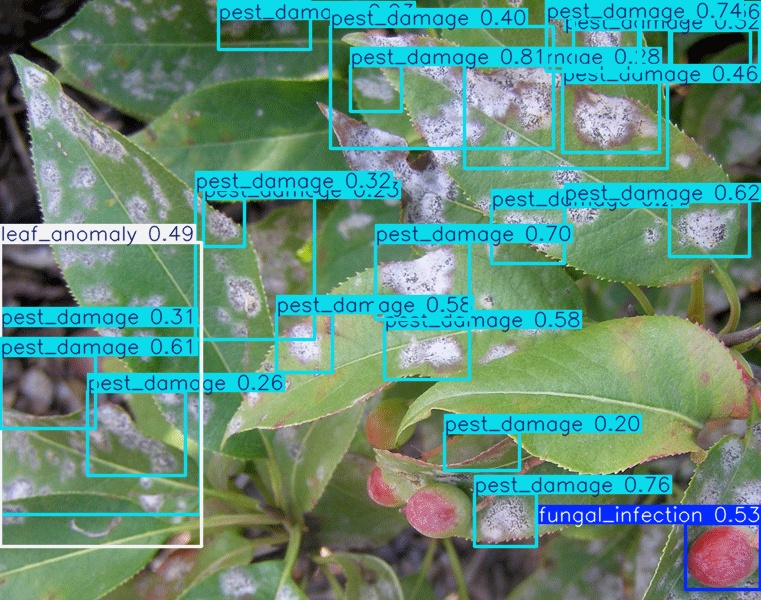

--------------------------------------------------
📄 File: image1.jpg
🔍 Detections found: 6


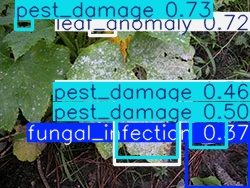

--------------------------------------------------
📄 File: image2.jpg
🔍 Detections found: 11


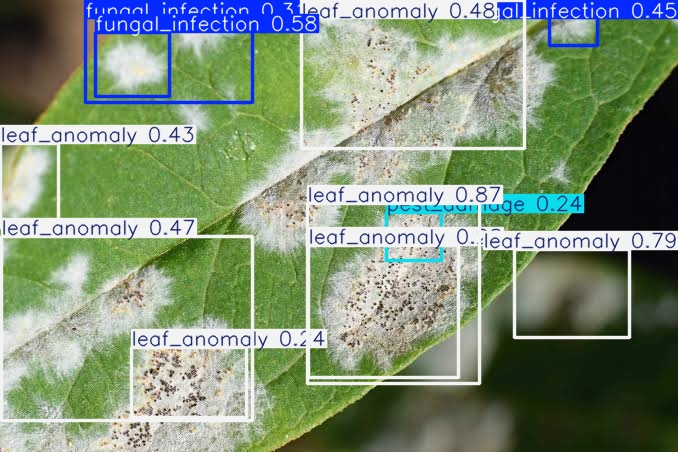

--------------------------------------------------
📄 File: image3.jpg
🔍 Detections found: 3


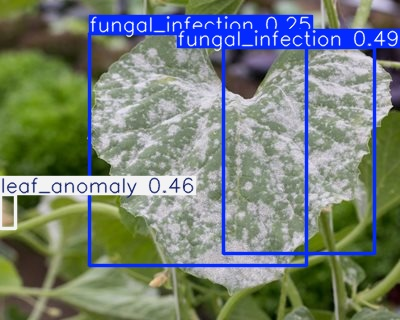

--------------------------------------------------
📄 File: image4.jpg
🔍 Detections found: 3


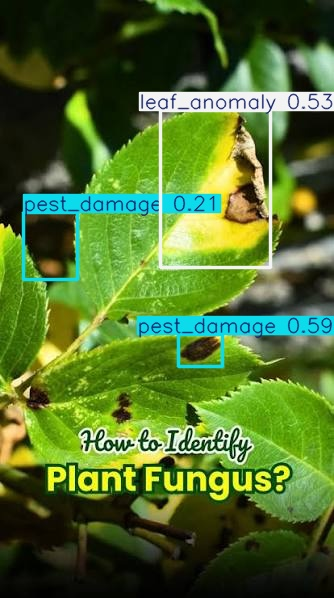

--------------------------------------------------
📄 File: image5.jpg
🔍 Detections found: 2


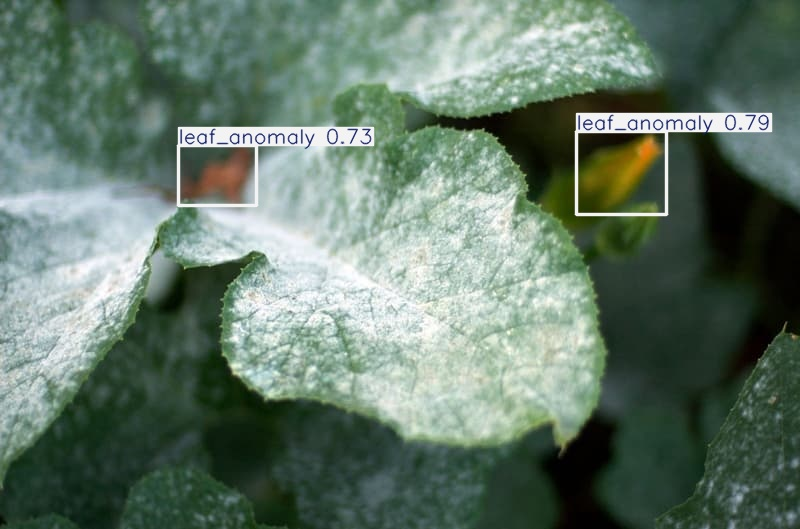

--------------------------------------------------
📄 File: image6.jpg
🔍 Detections found: 22


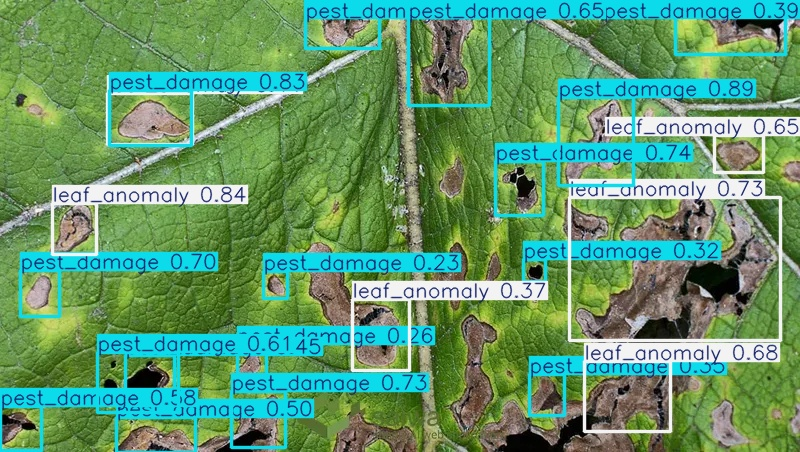

--------------------------------------------------
📄 File: image7.jpg
🔍 Detections found: 6


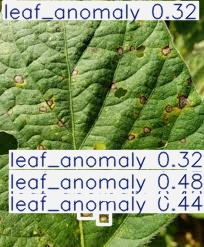

--------------------------------------------------
📄 File: image8.jpg
🔍 Detections found: 40


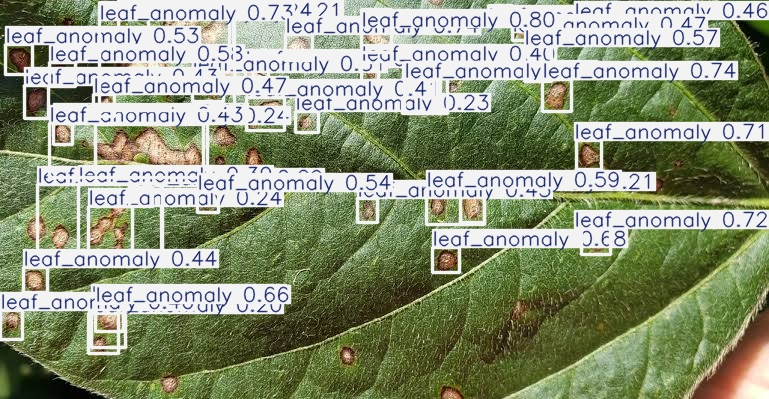

--------------------------------------------------
📄 File: image9.jpg
🔍 Detections found: 2


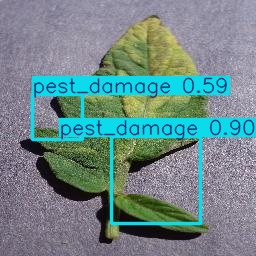

--------------------------------------------------
📄 File: image10.jpg
🔍 Detections found: 2


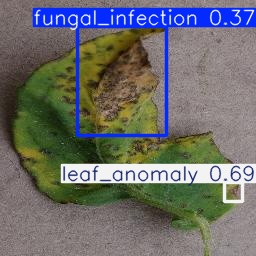

--------------------------------------------------


In [2]:
import os
from IPython.display import Image, display
from google.colab import files
from ultralytics import YOLO

# 1. Load model weights
model = YOLO("best.pt")

# 2. Upload images
uploaded = files.upload()
file_paths = list(uploaded.keys())

if file_paths:
    # 3. Run batch prediction on all uploaded files at once
    # 'exist_ok=True' prevents YOLO from making predict2, predict3 folders
    results = model.predict(
        source=file_paths,
        imgsz=800,
        conf=0.20,  # Slightly lower confidence threshold to catch subtle lesions
        save=True,
        name="predict",
        exist_ok=True,
    )

    # 4. Display annotated predictions dynamically from the output folder
    save_dir = results[0].save_dir
    print(f"\n✅ All predictions saved in: {save_dir}\n")

    for result in results:
        filename = os.path.basename(result.path)
        annotated_image_path = os.path.join(save_dir, filename)

        print(f"📄 File: {filename}")
        print(f"🔍 Detections found: {len(result.boxes)}")

        if os.path.exists(annotated_image_path):
            display(Image(filename=annotated_image_path))
        print("-" * 50)

In [ ]:
!rm -f *.jpg *.jpeg *.JPG *.JPEG